## 0. Setup Colab (RODE ESTA CÉLULA PRIMEIRO)
Monta o Google Drive, instala as dependências e confirma a GPU.
**Antes de rodar:** ative a T4 em Runtime → Change runtime type → T4 GPU.

In [1]:
# ===== SETUP COLAB (rodar primeiro) =====
# 1. Monta o Google Drive (checkpoints sobrevivem se a sessao cair)
from google.colab import drive
drive.mount("/content/drive")

# 2. Cria e entra na pasta de trabalho no Drive
import os
WORK = "/content/drive/MyDrive/Q4_destilacao"
os.makedirs(WORK, exist_ok=True)
os.chdir(WORK)
print("Pasta de trabalho:", os.getcwd())

# 3. Instala dependencias (SEM pin de versao - pega o compativel com Qwen2.5)
!pip install -q "transformers>=4.45,<4.48" "peft>=0.13,<0.15" datasets accelerate

# 4. Confirma GPU
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NENHUMA - ative a T4!")

# 5. Confirma que os arquivos necessarios estao na pasta
for arq in ["dataset_cot_limpo.json", "excluir_do_treino.json"]:
    print(arq, "encontrado" if os.path.exists(arq) else "FALTANDO - suba para esta pasta!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta de trabalho: /content/drive/MyDrive/Q4_destilacao
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
GPU: Tesla T4
dataset_cot_limpo.json encontrado
excluir_do_treino.json encontrado


# Questão 4 — Destilação de Conhecimento (CoT)
### Teacher: Qwen2.5-7B-Instruct → Student: Qwen2.5-0.5B-Instruct
**Tópicos em IA (2026.1) — DC/UFPI**
Grupo: Émery Moriconi, Eryck Torres, Felipe Lages, Raffael Fernandes

Este notebook faz a **destilação Step-by-Step (CoT)**: o student de 0.5B é treinado
por SFT+LoRA para imitar o *raciocínio + resposta* gerados pelo teacher de 7B.

**Pré-requisito:** `dataset_cot_limpo.json` (saída do `validar_dataset_cot.py`).

> Projetado para Colab/Kaggle (T4 16GB). Tem checkpointing e retomada.

## 1. Setup e dependências

In [2]:
# Em Colab/Kaggle, descomente:
# !pip install -q transformers==4.44.2 peft==0.12.0 datasets accelerate bitsandbytes

import os, json, random, math, time
import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Configuração central
Tudo que pode ser ajustado fica aqui, para reprodutibilidade e para citar no relatório.

In [3]:
STUDENT_ID   = "Qwen/Qwen2.5-0.5B-Instruct"   # student a ser destilado
DATASET_PATH = "dataset_cot_limpo.json"        # pares CoT validados
OUTPUT_DIR   = "student_cot_lora"              # checkpoints do treino
ADAPTER_DIR  = "student_cot_adapter"           # adapter final (leve)

MAX_LEN      = 512        # CoT é mais longo que SFT simples
EPOCHS       = 3
LR           = 2e-4       # padrão LoRA
BATCH        = 2          # por device (T4)
GRAD_ACCUM   = 8          # batch efetivo = 16
SAVE_STEPS   = 50
EVAL_STEPS   = 50
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

# Para sincronizar checkpoints no Drive (Colab), aponte OUTPUT_DIR para lá
# depois de montar: from google.colab import drive; drive.mount('/content/drive')

## 3. Carregar e dividir o dataset
Split 85/10/5 (treino/val/teste), igual à Q2/Q3. A seed fixa garante que o
conjunto de teste seja sempre o mesmo entre as variantes avaliadas.

In [4]:
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    dados = json.load(f)
print(f"Total de pares CoT: {len(dados)}")

Total de pares CoT: 1077


### 3.1 Anti-leakage (rodar ANTES do split)
Remove do dataset de treino as 100 perguntas reservadas ao benchmark.

In [5]:
# Anti-leakage: remove do treino as 100 perguntas que estão no benchmark
import re
def _norm(s): return re.sub(r"\s+", " ", s.strip().lower())
if os.path.exists("excluir_do_treino.json"):
    with open("excluir_do_treino.json", encoding="utf-8") as f:
        _excluir = set(json.load(f))
    _antes = len(dados)
    dados = [p for p in dados if _norm(p["instruction"]) not in _excluir]
    print(f"Anti-leakage: removidos {_antes-len(dados)} pares do benchmark; restam {len(dados)}")
else:
    print("AVISO: excluir_do_treino.json ausente — verifique leakage manualmente")

Anti-leakage: removidos 0 pares do benchmark; restam 1077


### 3.2 Split 85/10/5

In [6]:
random.Random(SEED).shuffle(dados)
n = len(dados)
n_tr = int(0.85 * n); n_val = int(0.10 * n)
treino = dados[:n_tr]
valid  = dados[n_tr:n_tr + n_val]
teste  = dados[n_tr + n_val:]
print(f"Treino {len(treino)} | Val {len(valid)} | Teste {len(teste)}")

# Persistir o split de teste — usado na avaliação
with open("split_teste.json", "w", encoding="utf-8") as f:
    json.dump(teste, f, ensure_ascii=False, indent=2)

Treino 915 | Val 107 | Teste 55


## 4. Tokenizer e template de prompt
Usamos o **chat template nativo do Qwen2.5**. O alvo de aprendizado é
`reasoning + Resposta: answer`. Mascaramos os tokens do prompt com `-100`
para que apenas a parte gerada pelo assistente conte na loss (mesma técnica da Q2/Q3).

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(STUDENT_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def montar_alvo(reasoning, answer):
    return f"{reasoning.strip()}\n\nResposta: {answer.strip()}"

def construir_prompt(instruction, inp=""):
    user_msg = instruction if not inp else f"{instruction}\n\n{inp}"
    return [{"role": "user", "content": user_msg}]

def _to_ids(x):
    """Normaliza saída do tokenizer para lista pura de ints."""
    if isinstance(x, dict) or hasattr(x, "input_ids"):
        x = x["input_ids"]
    if len(x) > 0 and isinstance(x[0], (list, tuple)):
        x = x[0]
    return list(x)

def tokenizar_par(par):
    msgs = construir_prompt(par["instruction"], par.get("input", ""))
    # gera o prompt como TEXTO e tokeniza (evita BatchEncoding do apply_chat_template)
    prompt_txt = tokenizer.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True
    )
    prompt_ids = _to_ids(tokenizer(prompt_txt, add_special_tokens=False))
    alvo = montar_alvo(par["reasoning"], par["answer"])
    alvo_ids = _to_ids(tokenizer(alvo, add_special_tokens=False))
    alvo_ids = alvo_ids + [tokenizer.eos_token_id]

    input_ids = prompt_ids + alvo_ids
    labels = [-100] * len(prompt_ids) + alvo_ids[:]  # mascara o prompt

    input_ids = input_ids[:MAX_LEN]
    labels = labels[:MAX_LEN]
    return {"input_ids": input_ids, "labels": labels,
            "attention_mask": [1] * len(input_ids)}

# Sanity check do comprimento
comprimentos = [len(tokenizar_par(p)["input_ids"]) for p in treino[:200]]
print(f"Comprimento (amostra): média {np.mean(comprimentos):.0f}, "
      f"máx {np.max(comprimentos)}, p95 {np.percentile(comprimentos,95):.0f}")
print(f"% truncados em {MAX_LEN}: "
      f"{100*np.mean([c>=MAX_LEN for c in comprimentos]):.1f}%")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Comprimento (amostra): média 173, máx 284, p95 225
% truncados em 512: 0.0%


## 5. Dataset e data collator
Collator com padding dinâmico por batch (mais eficiente que padding fixo).

In [8]:
from torch.utils.data import Dataset

class CoTDataset(Dataset):
    def __init__(self, pares):
        self.exemplos = [tokenizar_par(p) for p in pares]
    def __len__(self):
        return len(self.exemplos)
    def __getitem__(self, i):
        return self.exemplos[i]

def collator(batch):
    maxlen = max(len(b["input_ids"]) for b in batch)
    pad = tokenizer.pad_token_id
    input_ids, labels, attn = [], [], []
    for b in batch:
        dif = maxlen - len(b["input_ids"])
        input_ids.append(b["input_ids"] + [pad] * dif)
        labels.append(b["labels"] + [-100] * dif)
        attn.append(b["attention_mask"] + [0] * dif)
    return {
        "input_ids": torch.tensor(input_ids),
        "labels": torch.tensor(labels),
        "attention_mask": torch.tensor(attn),
    }

ds_treino = CoTDataset(treino)
ds_valid  = CoTDataset(valid)
print("Datasets prontos:", len(ds_treino), len(ds_valid))

Datasets prontos: 915 107


## 6. Carregar o student e aplicar LoRA
Carregamos o Qwen2.5-0.5B em fp16/bf16 e injetamos adaptadores LoRA nos
módulos de atenção e MLP. Apenas ~1-2% dos parâmetros ficam treináveis.

In [11]:
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
modelo = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID, torch_dtype=dtype, trust_remote_code=True
).to(DEVICE)
modelo.config.use_cache = False  # necessário com gradient checkpointing

lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj","k_proj","v_proj","o_proj",
                    "gate_proj","up_proj","down_proj"],
)
modelo = get_peft_model(modelo, lora_cfg)

# CORREÇÃO: com gradient checkpointing + LoRA, é preciso habilitar isto,
# senão o backward quebra ("does not require grad")
modelo.enable_input_require_grads()

modelo.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


## 7. Treino com checkpointing e retomada
`save_steps`/`save_total_limit` controlam os checkpoints. Se a sessão cair,
basta reexecutar a célula: `resume_from_checkpoint=True` retoma do último ponto
salvo em `OUTPUT_DIR`.

In [12]:
from transformers import Trainer, TrainingArguments

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=True,
    learning_rate=LR,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.01,
    max_grad_norm=1.0,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=(dtype==torch.bfloat16),
    fp16=(dtype==torch.float16),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=modelo, args=args,
    train_dataset=ds_treino, eval_dataset=ds_valid,
    data_collator=collator,
)

# Retomada automática: se houver checkpoint em OUTPUT_DIR, continua dele
ckpt_existe = os.path.isdir(OUTPUT_DIR) and any(
    d.startswith("checkpoint-") for d in os.listdir(OUTPUT_DIR)
) if os.path.isdir(OUTPUT_DIR) else False
print("Retomando de checkpoint" if ckpt_existe else "Treino do zero")

t0 = time.time()
trainer.train(resume_from_checkpoint=ckpt_existe)
print(f"Treino concluído em {(time.time()-t0)/60:.1f} min")

Treino do zero


Step,Training Loss,Validation Loss
50,1.477400,1.551735
100,1.277000,1.557919
150,1.155400,1.582525


Treino concluído em 16.8 min


## 8. Curvas de treino/validação
Para o relatório (mesmo formato visual da Q2/Q3).

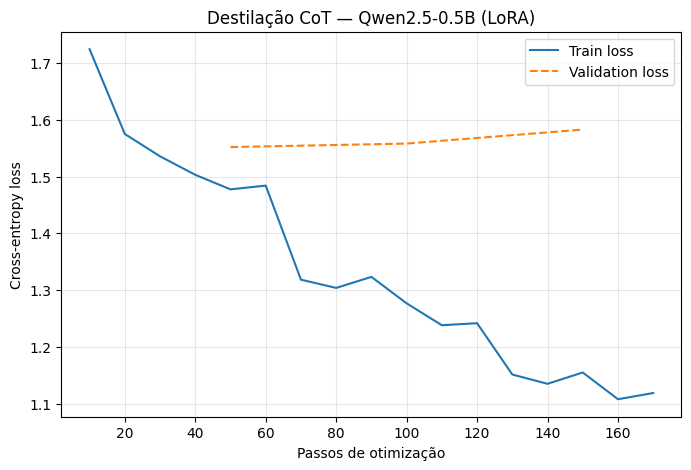

Melhor eval_loss: 1.5517 (passo 50) -> PPL val ~ 4.72


In [13]:
import matplotlib.pyplot as plt

hist = trainer.state.log_history
tr = [(h["step"], h["loss"]) for h in hist if "loss" in h]
ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

plt.figure(figsize=(8,5))
if tr: plt.plot(*zip(*tr), label="Train loss")
if ev: plt.plot(*zip(*ev), label="Validation loss", linestyle="--")
plt.xlabel("Passos de otimização"); plt.ylabel("Cross-entropy loss")
plt.title("Destilação CoT — Qwen2.5-0.5B (LoRA)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("q4_curva_treino.png", dpi=150, bbox_inches="tight")
plt.show()

if ev:
    best = min(ev, key=lambda x: x[1])
    print(f"Melhor eval_loss: {best[1]:.4f} (passo {best[0]}) "
          f"-> PPL val ~ {math.exp(best[1]):.2f}")

## 9. Salvar o adapter destilado
Salvamos apenas o adapter LoRA (poucos MB), fácil de versionar e de carregar
na avaliação.

In [14]:
modelo.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Adapter salvo em:", ADAPTER_DIR)

# Em Colab, copie para o Drive para não perder ao fim da sessão:
# !cp -r {ADAPTER_DIR} /content/drive/MyDrive/

Adapter salvo em: student_cot_adapter


## 10. Teste qualitativo rápido (sanity check)
Confirma que o student destilado já produz reasoning + resposta em português.
A avaliação completa (PPL, benchmark de 100, comparação com baseline e teacher)
fica no `avaliacao_q4.ipynb`.

In [15]:
modelo.config.use_cache = True
modelo.eval()

def responder(instrucao, max_new=256):
    msgs = construir_prompt(instrucao)
    ids = tokenizer.apply_chat_template(
        msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to(DEVICE)
    with torch.no_grad():
        out = modelo.generate(ids, max_new_tokens=max_new, do_sample=False,
                              repetition_penalty=1.15,
                              pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True)

for q in ["O que é uma árvore AVL e por que ela é usada?",
          "Qual a diferença entre processo e thread?"]:
    print("P:", q)
    print("R:", responder(q))
    print("-"*60)

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos toke

P: O que é uma árvore AVL e por que ela é usada?
R: A árvore AVL é um tipo de árvore binária onde cada nó tem um valor maior ou igual ao valor do nó pai. Isso significa que o tamanho médio da árvore não deve ultrapassar 2n-1, onde n é o número de nós na árvore.

Resposta: A árvore AVL utiliza essa propriedade para garantir que os valores dos nós sejam sempre menores ou iguais aos seus respectivos parenteses, reduzindo assim o tempo necessário para operações como inserção e remoção.
------------------------------------------------------------
P: Qual a diferença entre processo e thread?
R: Processo é um conceito mais amplo que envolve várias funções ou tarefas executadas simultaneamente em uma única máquina. Thread, por outro lado, é um recurso específico de hardware que permite que múltiplos processos sejam executados simultaneamente.

Resposta: Processo é o conjunto de funções ou tarefas executadas simultaneamente em uma única máquina, enquanto thread é um recurso específico do hardwa

In [18]:
import os
for arq in ["student_cot_adapter", "split_teste.json"]:
    print(arq, "OK" if os.path.exists(arq) else "FALTANDO")

student_cot_adapter OK
split_teste.json OK
